# deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B

In [1]:
import torch
from transformers import AutoTokenizer, AutoModel

C:\Users\Dell\OneDrive\Documents\TomDocuments\PythonProjects\PP\20260527\PatnaikPearson\ml_env311_v2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd
import random

In [3]:
import PatnaikPearson as pp
import cupy

In [4]:
# Config
N = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"

In [5]:
print(type(DEVICE))

<class 'torch.device'>


In [6]:
# Load model & tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(
    MODEL_NAME,
    output_hidden_states=True,
    torch_dtype=torch.float16,   # use fp16 to fit in GPU memory
).to(DEVICE)
model.eval()

Qwen2Model(
  (embed_tokens): Embedding(151936, 1536)
  (layers): ModuleList(
    (0-27): 28 x Qwen2DecoderLayer(
      (self_attn): Qwen2SdpaAttention(
        (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
        (k_proj): Linear(in_features=1536, out_features=256, bias=True)
        (v_proj): Linear(in_features=1536, out_features=256, bias=True)
        (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
        (rotary_emb): Qwen2RotaryEmbedding()
      )
      (mlp): Qwen2MLP(
        (gate_proj): Linear(in_features=1536, out_features=8960, bias=False)
        (up_proj): Linear(in_features=1536, out_features=8960, bias=False)
        (down_proj): Linear(in_features=8960, out_features=1536, bias=False)
        (act_fn): SiLU()
      )
      (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
    )
  )
  (norm): Qwen2RMSNorm((1536,), eps=1e-06)
)

In [15]:
xx = pp.DeepSeek_R1_Distill_Qwen_1_5B_token_embedding_layerwise_pp_dim_experiment(model, 
                                                                                  tokenizer,
                                                                                  DEVICE = DEVICE,
                                                                                  N = 2000,
                                                                                  num_iterations = 100)

vocab_size =  151643
iteration 0
iteration 1
iteration 2
iteration 3
iteration 4
iteration 5
iteration 6
iteration 7
iteration 8
iteration 9
iteration 10
iteration 11
iteration 12
iteration 13
iteration 14
iteration 15
iteration 16
iteration 17
iteration 18
iteration 19
iteration 20
iteration 21
iteration 22
iteration 23
iteration 24
iteration 25


KeyboardInterrupt: 

In [ ]:
# convert to a single dataframe

# create an empty dataframe
df = pd.DataFrame({
'value_type': [],
'layer_index': [],
'values': []
})

for this_key in xx:
    print(this_key)
    xx1 = xx[this_key]
    print(type(xx1))
    for layer_idx in xx1:
        xx2 = xx1[layer_idx]
        for yy in xx2:
            df.loc[len(df)] = [this_key, layer_idx, yy]

print(df.shape)
print(df.head(5))
print(df.tail(5))

# export to csv
file_name = 'pp_deepseek_r1_distill_qwen_1_5B_layers.csv'
df.to_csv(file_name, index=False)

In [ ]:
layer_pp_dim_title = "DeepSeek-R1-Distill-Qwen-1.5B : layerwise average and std dev Patnaik-Pearson dimension\n"
layer_pp_dim_title += "Embedding dim d = 1536, Num tokens N = 2000, num samples = 3"

layer_pp_dim_image_name = "just_testing.pdf"

pp.plot_per_layer_graphs(df, num_layers = 29,
                          this_key = 'layer_pp_dim', 
                          this_title = layer_pp_dim_title, 
                          this_image_name  = layer_pp_dim_image_name)

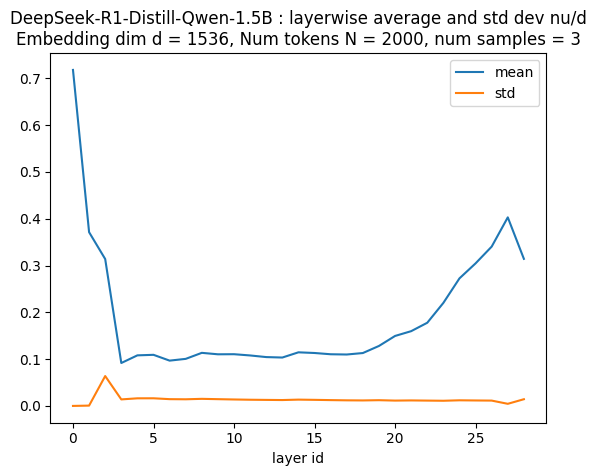

In [14]:
layer_nu_over_d_title = "DeepSeek-R1-Distill-Qwen-1.5B : layerwise average and std dev nu/d\n"
layer_nu_over_d_title += "Embedding dim d = 1536, Num tokens N = 2000, num samples = 3"

layer_nu_over_d_image_name = "just_testing.pdf"

pp.plot_per_layer_graphs(df, num_layers = 29,
                          this_key = 'layer_nu_over_d', 
                          this_title = layer_nu_over_d_title, 
                          this_image_name  = layer_nu_over_d_image_name)

# ** OLD AND SPARE **

In [ ]:
# Sample N random token IDs
vocab_size = tokenizer.vocab_size
print("vocab_size = ", vocab_size)
random_token_ids = torch.randint(0, vocab_size, (N,), dtype=torch.long)
print("Sampled token IDs:", random_token_ids.tolist())
print("Sampled tokens:   ", tokenizer.convert_ids_to_tokens(random_token_ids.tolist()))

In [ ]:
# Build input
input_ids      = random_token_ids.unsqueeze(0).to(DEVICE)       # (1, N)
print(input_ids.shape)
print(input_ids)
attention_mask = torch.ones(1, N, dtype=torch.long).to(DEVICE)

In [ ]:
# Forward pass
with torch.no_grad():
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)

In [ ]:
# Extract per-layer representations
# hidden_states: tuple of (num_layers + 1) tensors, each shape (1, N, 1536)
hidden_states = outputs.hidden_states
print(len(hidden_states))

In [ ]:
for hs in hidden_states:
    print(type(hs), hs.shape)

In [ ]:
layer_representations = {}
for layer_idx, hs in enumerate(hidden_states):
    layer_representations[layer_idx] = hs.squeeze(0)  # (N, 1536)

In [ ]:
print(type(layer_representations))
print(len(layer_representations))

In [ ]:
# ── Inspect ───────────────────────────────────────────────────────────────────
print(f"\nNumber of layers (incl. embedding): {len(layer_representations)}")
for layer_idx, rep in layer_representations.items():
    label = "embedding" if layer_idx == 0 else f"layer {layer_idx}"
    print(f"  {label:10s} → shape {tuple(rep.shape)}")

In [ ]:
layer_pp_dim = {}
layer_nu_over_d = {}
for layer_idx, rep in layer_representations.items():
    print(layer_idx, type(rep))
    # matrix = np.eye(2, dtype=np.float16)
    #result = np.linalg.inv(matrix.astype(np.float32)).astype(np.float16)
    np_rep = (rep.cpu().numpy()).astype(np.float32)
    print(type(np_rep), np_rep.shape)
    dim_rep = np_rep.shape[1]
    pp_dim_rep = pp.calculate_PatnaikPearson_dim(np_rep)
    nu_over_d_rep = pp_dim_rep / dim_rep
    print("pp_dim_rep = ", pp_dim_rep, ", nu_over_d_rep = ",nu_over_d_rep)
    layer_pp_dim[layer_idx] = float(pp_dim_rep)
    layer_nu_over_d[layer_idx] = float(nu_over_d_rep)

In [ ]:
print(type(model))
print(type(tokenizer))

In [ ]:
xx = DeepSeek_R1_Distill_Qwen_1_5B_token_embedding_layerwise_pp_dim_experiment(model,
                                                                               tokenizer,
                                                                               N = 2000,
                                                                               num_iterations = 3)

In [ ]:
# convert to a single dataframe

# create an empty dataframe
df = pd.DataFrame({
'value_type': [],
'layer_index': [],
'values': []
})

for this_key in xx:
    print(this_key)
    xx1 = xx[this_key]
    print(type(xx1))
    for layer_idx in xx1:
        xx2 = xx1[layer_idx]
        for yy in xx2:
            df.loc[len(df)] = [this_key, layer_idx, yy]

print(df.shape)
print(df.head(5))
print(df.tail(5))

# export to csv
file_name = 'pp_deepseek_r1_distill_qwen_1_5B_layers.csv'
#df.to_csv(file_name, index=False)

In [ ]:
layer_pp_dim_title = "DeepSeek-R1-Distill-Qwen-1.5B : layerwise average and std dev Patnaik-Pearson dimension\n"
layer_pp_dim_title += "Embedding dim d = 1536, Num tokens N = 2000, num samples = 3"

layer_pp_dim_image_name = "just_testing.pdf"

plot_per_layer_graphs(df, num_layers = 13,
                          this_key = 'layer_pp_dim', 
                          this_title = layer_pp_dim_title, 
                          this_image_name  = layer_pp_dim_image_name)

In [ ]:
def plot_per_layer_graphs(df : pd.DataFrame, 
                          num_layers : int,
                          this_key : str, 
                          this_title : str, 
                          this_image_name : str):

    #this_key = 'layer_pp_dim'
    #this_title = "Needs title"
    #this_image_name = "test.pdf"

    this_df = df.loc[df['value_type'] == this_key]
    #print(this_df.shape)
    #print(this_df.head(3))
    #print(this_df.tail(3))
    #num_layers = 13 # layers are 0 to 12 inclusive
    layer_idx_vals = np.arange(0,num_layers,1)
    #print(layer_idx_vals)
    layer_mean_vals = np.zeros(num_layers)
    layer_std_vals = np.zeros(num_layers)

    for layer_idx in layer_idx_vals:
        df_this_layer = (this_df.loc[this_df['layer_index'] == layer_idx])["values"]
        layer_mean = df_this_layer.mean()
        layer_std = df_this_layer.std()
        #print(layer_idx, df_this_layer.shape, layer_mean, layer_std)
        layer_mean_vals[layer_idx] = layer_mean
        layer_std_vals[layer_idx] = layer_std
        #print(df_this_layer)

    plt.plot(layer_idx_vals, layer_mean_vals, label = "mean")
    plt.plot(layer_idx_vals, layer_std_vals, label = "std")
    plt.xlabel("layer id")
    plt.legend()
    plt.title(this_title)
    plt.savefig(this_image_name, dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
def DeepSeek_R1_Distill_Qwen_1_5B_token_embedding_layerwise_pp_dim_experiment(model : 'transformers.models.qwen2.modeling_qwen2.Qwen2Model', 
                                                     tokenizer : 'transformers.models.llama.tokenization_llama_fast.LlamaTokenizerFast',
                                                     N : int = 2000, 
                                                     num_iterations : int = 1,
                                                    ):

    max_N = 130000 # max context length
    N = min(N, max_N)

    vocab_size = tokenizer.vocab_size
    #random_token_ids = torch.randint(0, vocab_size, (N,), dtype=torch.long)

    #valid_bert_base_token_ids = pp.get_valid_bert_base_token_ids()
    #vocab_size = len(valid_bert_base_token_ids)
    print("vocab_size = ", vocab_size)
    attention_mask = torch.ones(1, N, dtype=torch.long).to(DEVICE)     # no padding

    layer_pp_dim = {}
    layer_nu_over_d = {}
    layer_nu_over_N = {}
    num_layers = 29
    for layer_id in range(0,num_layers + 1):
        layer_pp_dim[layer_id] = np.zeros(num_iterations)
        layer_nu_over_d[layer_id] = np.zeros(num_iterations)
        layer_nu_over_N[layer_id] = np.zeros(num_iterations)

    for i in range(num_iterations):
        print("iteration " + str(i))
        #random_indices = np.random.choice(vocab_size, N, replace = False)
        #np_random_token_ids = np.zeros(len(random_indices))
        #count = 0
        #for ridx in random_indices:
        #    np_random_token_ids[count] = valid_bert_base_token_ids[ridx]
        #    count+=1
        #np_random_token_ids 
        random_token_ids = torch.randperm(vocab_size, dtype=torch.long)[:N]
        
        #torch.randint(0, vocab_size, (N,), dtype=torch.long)
        #print("np_random_token_ids : max = ", np.max(np_random_token_ids), ", min = ", np.min(np_random_token_ids) , 
        #      ", mean = ", np.mean(np_random_token_ids), ", std = ", np.std(np_random_token_ids))
        
        #random_token_ids = torch.tensor(np_random_token_ids, dtype=torch.long)

        input_ids = random_token_ids.unsqueeze(0).to(DEVICE)          # (1, N)
        # attention_mask = torch.ones(1, N, dtype=torch.long).to(DEVICE)     # no padding
        # Forward pass
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        # ── Extract per-layer representations ────────────────────────────────────────
        # hidden_states is a tuple of (num_layers + 1) tensors, each shape (1, N, 768)
        # Index 0 = embedding layer, indices 1–12 = transformer layers 1–12
        hidden_states = outputs.hidden_states  # tuple of 13 tensors
        layer_representations = {}
        for layer_idx, hs in enumerate(hidden_states):
            #layer_representations[layer_idx] = hs.squeeze(0)  # shape: (N, 768)
            rep = hs.squeeze(0)
        #for layer_idx, rep in layer_representations.items():
            #print(layer_idx, type(rep))
            np_rep = rep.cpu().numpy().astype(np.float32)
            #print(type(np_rep), np_rep.shape)
            dim_rep = np_rep.shape[1]
            pp_dim_rep = float(pp.calculate_PatnaikPearson_dim(np_rep))
            nu_over_d_rep = pp_dim_rep / dim_rep
            nu_over_N_rep = pp_dim_rep / N
            #print("pp_dim_rep = ", pp_dim_rep, ", nu_over_d_rep = ",nu_over_d_rep)
            layer_pp_dim[layer_idx][i] = pp_dim_rep
            layer_nu_over_d[layer_idx][i] = nu_over_d_rep
            layer_nu_over_N[layer_idx][i] = nu_over_N_rep

    results_dict = {
            "layer_pp_dim" : layer_pp_dim,
            "layer_nu_over_d" : layer_nu_over_d,
            "layer_nu_over_N" : layer_nu_over_N
        }

    return results_dict